# Imports

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.sparse import coo_matrix
import random
import numpy as np
import pickle
import time
from scipy.special import expit
from pathlib import Path

# Load Item Data

In [3]:
import os
# os.listdir("/content/drive")

In [4]:
os.getcwd()

'/user/yagelalfasi/DL2_Project/Amazon'

In [5]:
items_df = pd.read_json("items_metadata.jsonl", lines=True)

## Initial introduction and inspection

In [6]:
# print(items_df)

In [7]:
items_df.head(5)

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,AMAZON FASHION,BALEAF Women's Long Sleeve Zip Beach Coverup U...,4.2,422,"[90% Polyester, 10% Spandex, Zipper closure, M...",[],31.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Women's UPF 50+ Front Zip Beach Co...,BALEAF,"[Clothing, Shoes & Jewelry, Women, Clothing, S...","{'Department': 'womens', 'Date First Available...",B09X1MRDN6,NaN,NaN,NaN
1,AMAZON FASHION,"SAS Women's, Relaxed Sandal",4.7,618,"[Made in the USA, Suede sole, Heel measures ap...","[Unwind, leave your worries behind, and simply...",188.95,[{'thumb': 'https://m.media-amazon.com/images/...,[],SAS,"[Clothing, Shoes & Jewelry, Women, Shoes, Sand...",{'Product Dimensions': '10 x 15 x 6 inches; 2 ...,B0944VG4Y4,NaN,NaN,NaN
2,AMAZON FASHION,SheIn Women's Basic Stretch Plaid Mini Bodycon...,3.8,999,"[Zipper closure, Fabric has some stretch; Plea...",[],12.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'SUPER CUTE plaid skirt!', 'url': '...",SheIn,"[Clothing, Shoes & Jewelry, Novelty & More, Cl...","{'Department': 'womens', 'Date First Available...",B08JGGF5TJ,NaN,NaN,NaN
3,AMAZON FASHION,Amazon Essentials Women's Surplice Dress (Avai...,4.4,7096,"[95% Viscose, 5% Elastane, Imported, No Closur...",[Amazon Essentials is focused on creating affo...,19.92,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Easy throw on dress! Comfortable, ...",Amazon Essentials,"[Clothing, Shoes & Jewelry, Women, Clothing, D...","{'Item model number': 'AE1932668', 'Department...",B096HDRB6R,NaN,NaN,NaN
4,AMAZON FASHION,"Fotociti Yoga Shorts for Women – 5"" High Waist...",4.5,2911,"[92% Polyester, 8% Spandex, Imported, Pull On ...",[],15.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Cute Blue Camo Yoga Bike Shorts Re...,Fotociti,"[Clothing, Shoes & Jewelry, Women, Clothing, A...",{'Package Dimensions': '10 x 8 x 0.6 inches; 7...,B089YJ8P6X,NaN,NaN,NaN


In [8]:
num_rows, num_columns = items_df.shape
# Print the number of rows and columns of the DataFrame
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_columns}")

# Print the shape of the DataFrame
print(f"Shape of the DataFrame: {items_df.shape}")

Number of rows: 220890
Number of columns: 16
Shape of the DataFrame: (220890, 16)


In [9]:
#Check the data types
print("Column names:")
print(list(items_df.columns)) # This prints only the columns names of the df

print("\nData types of each column:")
print(items_df.dtypes)

Column names:
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']

Data types of each column:
main_category       object
title               object
average_rating     float64
rating_number        int64
features            object
description         object
price               object
images              object
videos              object
store               object
categories          object
details             object
parent_asin         object
bought_together    float64
subtitle            object
author              object
dtype: object


### Descriptive statistics

In [10]:
# General dataset overview
items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220890 entries, 0 to 220889
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   main_category    214497 non-null  object 
 1   title            220890 non-null  object 
 2   average_rating   220890 non-null  float64
 3   rating_number    220890 non-null  int64  
 4   features         220890 non-null  object 
 5   description      220890 non-null  object 
 6   price            160693 non-null  object 
 7   images           220890 non-null  object 
 8   videos           220890 non-null  object 
 9   store            220147 non-null  object 
 10  categories       220890 non-null  object 
 11  details          220890 non-null  object 
 12  parent_asin      220890 non-null  object 
 13  bought_together  0 non-null       float64
 14  subtitle         123 non-null     object 
 15  author           9 non-null       object 
dtypes: float64(2), int64(1), object(13)
me

In [11]:
items_df.main_category.unique()

array(['AMAZON FASHION', 'All Beauty', 'Amazon Home', None,
       'Toys & Games', 'Sports & Outdoors', 'Computers',
       'Industrial & Scientific', 'Health & Personal Care', 'Automotive',
       'Office Products', 'Arts, Crafts & Sewing', 'All Electronics',
       'Baby', 'Tools & Home Improvement', 'Cell Phones & Accessories',
       'Books', 'Video Games', 'Grocery', 'Handmade',
       'Musical Instruments', 'Camera & Photo', 'Appliances',
       'Amazon Devices', 'Premium Beauty', 'GPS & Navigation',
       'Home Audio & Theater', 'Unique Finds', 'Movies & TV',
       'Collectible Coins', 'Car Electronics'], dtype=object)

In [12]:
items_df.main_category.value_counts()

main_category
AMAZON FASHION               202642
Sports & Outdoors              2315
Amazon Home                    2219
Toys & Games                   1775
Tools & Home Improvement       1574
All Beauty                     1074
Health & Personal Care          662
Office Products                 553
Arts, Crafts & Sewing           398
Books                           224
Industrial & Scientific         223
Baby                            207
Cell Phones & Accessories       179
Automotive                      177
Computers                       111
All Electronics                  69
Musical Instruments              26
Handmade                         21
Camera & Photo                   11
Grocery                          11
Video Games                       5
Appliances                        4
Home Audio & Theater              4
Movies & TV                       4
Amazon Devices                    2
Unique Finds                      2
Collectible Coins                 2
Premium Beauty

### Check missing values

In [13]:
# Calculate the total number of missing values per column
missing_counts = items_df.isnull().sum()

# Calculate the proportion of missing values (as a percentage)
missing_proportion = missing_counts / items_df.shape[0]

# Create a new DataFrame with the desired columns
result_df = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Proportion (%)": round(missing_proportion*100,2)
})

display(result_df)

,Missing Count,Missing Proportion (%)
main_category,6393,2.89
title,0,0.00
average_rating,0,0.00
rating_number,0,0.00
features,0,0.00
description,0,0.00
price,60197,27.25
images,0,0.00
videos,0,0.00
store,743,0.34


In [14]:
def df_to_plotly_table(
    df,
    title=None,
    max_rows=None,
    decimals=2,
    include_index=True,
    height="auto"
):
    df_disp = df.copy()

    if max_rows is not None:
        df_disp = df_disp.head(max_rows)

    if include_index:
        df_disp = df_disp.reset_index()

        first_col = df_disp.columns[0]
        if str(first_col).lower() == "index":
            df_disp = df_disp.rename(columns={first_col: ""})

    num_cols = df_disp.select_dtypes(include="number").columns
    df_disp[num_cols] = df_disp[num_cols].round(decimals)
    for c in num_cols:
        df_disp[c] = df_disp[c].map(lambda x: f"{x:.{decimals}f}" if x is not None else x)

    if height == "auto":
        height = 120 + len(df_disp) * 24

    fig = go.Figure(data=[go.Table(
        header=dict(values=list(df_disp.columns)),
        cells=dict(values=[df_disp[col] for col in df_disp.columns])
    )])

    fig.update_layout(
        title=title,
        height=height,
        margin=dict(l=8, r=8, t=35 if title else 8, b=8)
    )
    return fig

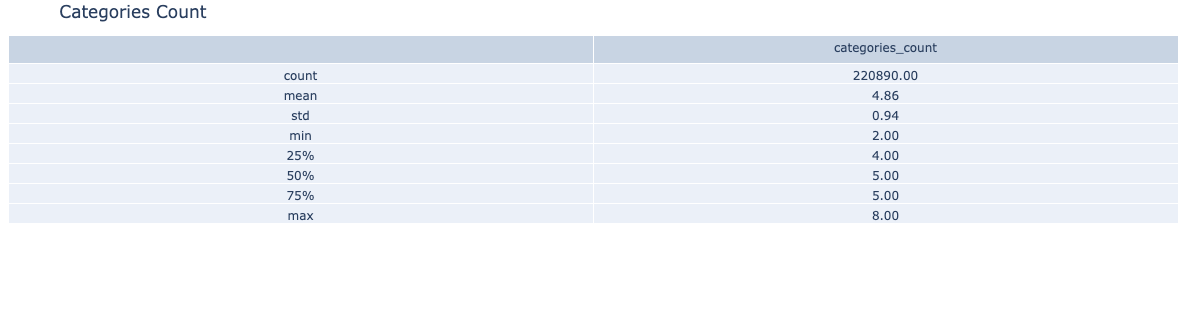

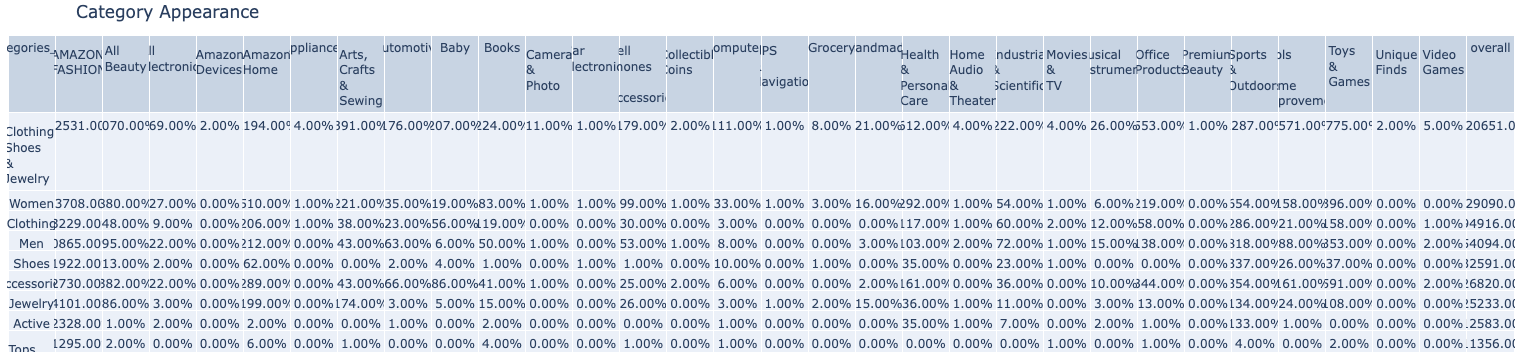

The number of unique categories is: 1103


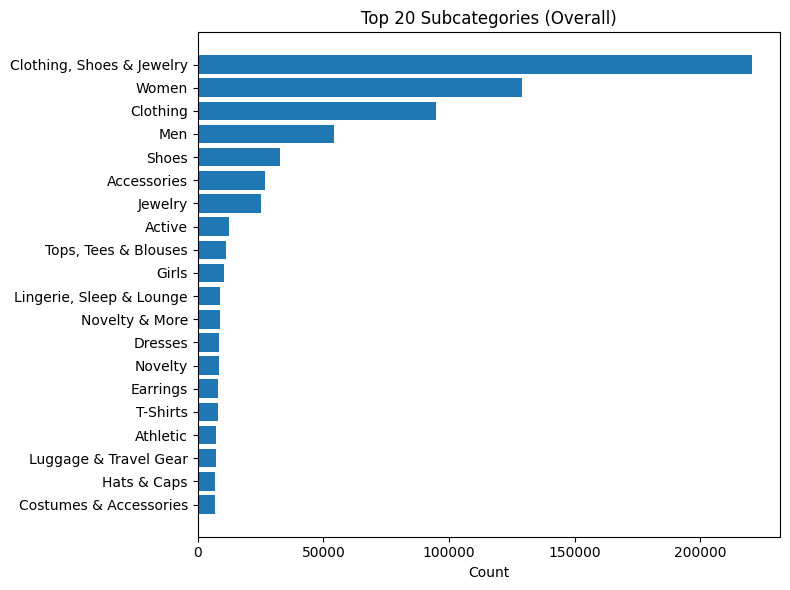

{'Green Lit 193', 'Womens Next-Gen Trends', 'Scrub Jackets', 'Cuffs & Wraps', 'Button-Down Shirts', 'Top-Handle Bags', 'Ties, Cummerbunds & Pocket Squares', 'Briefcases', "20% Off President's Day Savings | Women", '4th of July Up to 60% Off', 'Snow Pants & Bibs', 'Leotards', 'Swimwear', 'Footies & Rompers', 'Dress Coats', 'Streetwear Style: Accessories', "Men's Swimwear", 'Active Base Layers', '4+ Stars: Clothes, Shoes and Jewelry', 'Amazon Fashion Deals', 'Fashion Under $100', 'Gray dresses', 'Hoodies', 'Handpicked Diamond Jewelry', 'Waterproof Jackets', 'Wrist Watches', 'Dress Shirts', 'All-Gender Kids', 'Wallets', 'Collars', 'Cold Weather Headbands', 'Headwraps', 'Top Daring Lingerie', "Women's Leather Watches for Spring", "20% Off $100 Women's & Men's", 'Costumes & Cosplay Apparel', 'Windbreakers', "Women's Halloween Costumes", 'Cosmo Fashion- December', 'Baseball', 'Shoe & Boot Trees', 'Amazon Private and Exclusive Brands', 'Berets', 'Keyrings, Keychains & Charms', 'MFN Only', 'Br

In [15]:
items_df["categories_list"] = items_df["categories"].apply(
    lambda x: x if isinstance(x, list) else []
)

# How many names per item
items_df["categories_count"] = items_df["categories_list"].apply(len)
fig1 = df_to_plotly_table(items_df["categories_count"].describe(), "Categories Count")
fig1.show()


# Overall frequency
categories_freq = items_df.explode("categories_list")["categories_list"].value_counts()

# Count per label for each country
categoriesy_by_label = (
    items_df.explode("categories_list")
      .groupby(["categories_list", "main_category"])
      .size()
      .unstack(fill_value=0)   # columns = labels
)

categories_by_label = categoriesy_by_label.div(categories_freq, axis=0) * 100


# Limit to top N overall and keep the label columns
top_n = 50
categories_by_label_top = categoriesy_by_label.loc[categories_freq.head(top_n).index]
categories_by_label_pct_top_fmt = categories_by_label_top.map(lambda x: f"{x:.2f}%")
categories_by_label_pct_top_fmt['overall'] = categories_freq
fig2 = df_to_plotly_table(categories_by_label_pct_top_fmt[:10], 'Category Appearance')
fig2.show()

all_categories = set()
items_df["categories_list"].apply(lambda x: all_categories.update(x))
print(f"The number of unique categories is: {len(all_categories)}")

categories_counts = (
    items_df.explode("categories_list")["categories_list"]
      .value_counts()
      .head(20)
      .sort_values()
)

plt.figure(figsize=(8, 6))
plt.barh(categories_counts.index, categories_counts.values)
plt.title("Top 20 Subcategories (Overall)")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

print(all_categories)

## Remove columns

These columns are 100% or ~100% missing:

In [16]:
items_df = items_df.drop(columns=["bought_together", "subtitle", "author"])

## Isolate Fashion cleanly

In [17]:
items_fashion_df = items_df[items_df["main_category"] == "AMAZON FASHION"].copy()

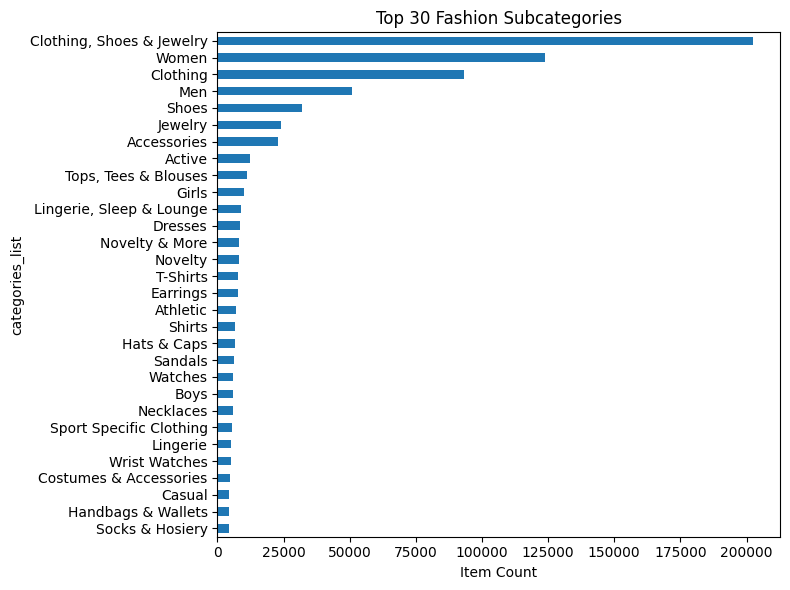

In [18]:
# Fashion only subcategories
fashion_cat_freq = (
    items_fashion_df.explode("categories_list")["categories_list"]
      .value_counts()
)

plt.figure(figsize=(8,6))
fashion_cat_freq.head(30).sort_values().plot.barh()
plt.title("Top 30 Fashion Subcategories")
plt.xlabel("Item Count")
plt.tight_layout()
plt.show()


In [19]:
items_fashion_df["category_depth"] = items_fashion_df["categories_list"].apply(len)

items_fashion_df["category_depth"].describe()

count    202642.000000
mean          4.900633
std           0.931376
min           2.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           8.000000
Name: category_depth, dtype: float64

In [20]:
# Number of unique subcategories in Fashion
unique_fashion_categories = (
    items_fashion_df.explode("categories_list")["categories_list"]
      .dropna()
      .unique()
)

print(f"Number of unique Fashion subcategories: {len(unique_fashion_categories)}")

Number of unique Fashion subcategories: 1051


In [21]:
unique_fashion_categories[:50]

array(['Clothing, Shoes & Jewelry', 'Women', 'Clothing',
       'Swimsuits & Cover Ups', 'Cover-Ups', 'Shoes', 'Sandals', 'Flats',
       'Novelty & More', 'Novelty', 'Skirts', 'Dresses', 'Casual',
       'Active', 'Active Shorts', 'Athletic', 'Running', 'Road Running',
       'Men', 'Active Shirts & Tees', 'T-Shirts', 'Sweaters', 'Cardigans',
       'Girls', 'Racquet Sports', 'Tops, Tees & Blouses', 'Tanks & Camis',
       'Blouses & Button-Down Shirts', 'Lingerie, Sleep & Lounge',
       'Lingerie', 'Panties', 'Briefs', 'Accessories', 'Hats & Caps',
       'Skullies & Beanies', 'Uniforms, Work & Safety', 'Medical',
       'Scrub Tops', 'Camisoles & Tanks', 'Pants', 'Tops & Tees',
       'Bikinis', 'Sets', 'Walking', 'Slides', 'Westlake',
       'Athletic Socks', 'Cold Weather Headbands', 'Fashion Sneakers',
       'Bras'], dtype=object)

In [22]:
items_fashion_df.isna().sum()

main_category           0
title                   0
average_rating          0
rating_number           0
features                0
description             0
price               53792
images                  0
videos                  0
store                 499
categories              0
details                 0
parent_asin             0
categories_list         0
categories_count        0
category_depth          0
dtype: int64

## Prune Categories

Here we prune categories before building matrices.
Without pruning:
    - Category matrix will have thousands of columns
    - Many columns will have <10 nonzeros
    - MF regularization will fail
    - Optimization becomes unstable
    - Side info becomes noise, not signal

In [23]:
fashion_cat_freq = (
    items_fashion_df
    .explode("categories_list")["categories_list"]
    .value_counts()
)

fashion_cat_freq

categories_list
Clothing, Shoes & Jewelry                                            202531
Women                                                                123708
Clothing                                                              93229
Men                                                                   50865
Shoes                                                                 31922
                                                                      ...  
Video Game T-Shirts                                                       1
REDO W GENZ SHOES                                                         1
Deal of The Day l Up to 49% off Sparkling Sterling Silver Jewelry         1
Onesies                                                                   1
Sensational Steals                                                        1
Name: count, Length: 1051, dtype: int64

In [24]:
MIN_CATEGORY_ITEMS = 40


valid_categories = fashion_cat_freq[
    fashion_cat_freq >= MIN_CATEGORY_ITEMS
].index

print(f"The number of unique categories in the full item dataset are: {fashion_cat_freq.shape[0]}")
print(f"The number of categories that passed the threshold are: {len(valid_categories)}")

The number of unique categories in the full item dataset are: 1051
The number of categories that passed the threshold are: 500


In [25]:
items_fashion_df["categories_list_pruned"] = (
    items_fashion_df["categories_list"]
    .apply(lambda xs: [x for x in xs if x in valid_categories])
)

# Drop items that lost all categories
items_fashion_cleaned_df = items_fashion_df[
    items_fashion_df["categories_list_pruned"].apply(len) > 0
].copy()

In [26]:
items_fashion_cleaned_df.shape

(202642, 17)

## Save file

In [27]:
# items_fashion_cleaned_df.to_csv('/content/drive/MyDrive/Colab Notebooks/movielens1m/Amazon Fashion/Amazon_items_cleaned.csv', index=False)

# Load Rating Data

In [28]:
rating_df = pd.read_csv( "user_item_rating_table_train (1).csv")

In [29]:
rating_df.head()

,Unnamed: 0,user_id,parent_asin,rating,timestamp
0,0,AGGZ357AO26RQZVRLGU4D4N52DZQ,B009RTBRVG,5.0,1.349042e+12
1,1,AGGZ357AO26RQZVRLGU4D4N52DZQ,B003MZ01CM,1.0,1.370959e+12
2,2,AGGZ357AO26RQZVRLGU4D4N52DZQ,B07L6QT33F,5.0,1.440039e+12
3,3,AGGZ357AO26RQZVRLGU4D4N52DZQ,B07V6PKCCG,3.0,1.483321e+12
4,5,AGGZ357AO26RQZVRLGU4D4N52DZQ,B0BNP511CS,5.0,1.490801e+12


## Shape & Sparsity

In [30]:
num_rows, num_columns = rating_df.shape
# Print the number of rows and columns of the DataFrame
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_columns}")

# Print the shape of the DataFrame
print(f"Shape of the DataFrame: {rating_df.shape}")

Number of rows: 8293304
Number of columns: 5
Shape of the DataFrame: (8293304, 5)


In [31]:
n_users = rating_df["user_id"].nunique()
n_items = rating_df["parent_asin"].nunique()
n_interactions = len(rating_df)

density = n_interactions / (n_users * n_items)

print(f"Users: {n_users}")
print(f"Items: {n_items}")
print(f"Interactions: {n_interactions}")
print(f"Density: {density:.6e}")

Users: 964040
Items: 198771
Interactions: 8293304
Density: 4.327923e-05


In [32]:
rating_df["rating"].describe()

count    8.293303e+06
mean     4.321840e+00
std      1.139525e+00
min      1.000000e+00
25%      4.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

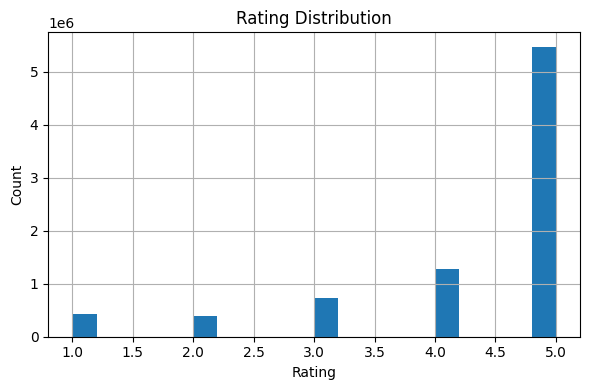

In [33]:
# Plot rating distribution
plt.figure(figsize=(6,4))
rating_df["rating"].hist(bins=20)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [34]:
# User activity distribution
user_activity = (
    rating_df["user_id"]
    .value_counts()
)

user_activity.describe()

count    964040.000000
mean          8.602654
std           8.744622
min           1.000000
25%           5.000000
50%           6.000000
75%          10.000000
max        1438.000000
Name: count, dtype: float64

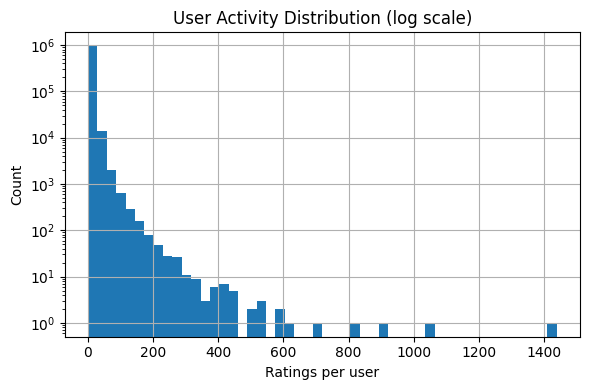

In [35]:
# Plot on log scale
plt.figure(figsize=(6,4))
user_activity.hist(bins=50, log=True)
plt.title("User Activity Distribution (log scale)")
plt.xlabel("Ratings per user")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [36]:
# Item popularity distribution
item_popularity = (
    rating_df["parent_asin"]
    .value_counts()
)

item_popularity.describe()

count    198771.000000
mean         41.722902
std         104.002615
min           2.000000
25%          12.000000
50%          18.000000
75%          33.000000
max        5658.000000
Name: count, dtype: float64

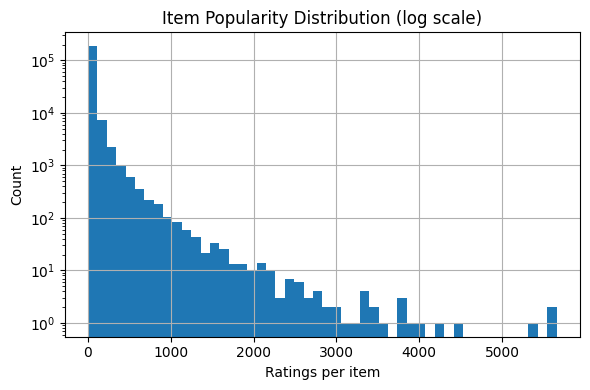

In [37]:
# Plot on log scale
plt.figure(figsize=(6,4))
item_popularity.hist(bins=50, log=True)
plt.title("Item Popularity Distribution (log scale)")
plt.xlabel("Ratings per item")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Prune Items & Users

In [38]:
MIN_USER_INTERACTIONS = 3
MIN_ITEM_INTERACTIONS = 5

In [39]:
user_counts = rating_df["user_id"].value_counts()
item_counts = rating_df["parent_asin"].value_counts()

valid_users = user_counts[user_counts >= MIN_USER_INTERACTIONS].index
valid_items = item_counts[item_counts >= MIN_ITEM_INTERACTIONS].index

ratings_cleaned_df = rating_df[
    rating_df["user_id"].isin(valid_users) &
    rating_df["parent_asin"].isin(valid_items)
].copy()

In [40]:
# Align item metadata with filtered items
items_fashion_cleaned_df = items_fashion_cleaned_df[
    items_fashion_cleaned_df["parent_asin"].isin(valid_items)
].copy()

In [41]:
# items_fashion_cleaned_df.to_csv('/content/drive/MyDrive/Colab Notebooks/movielens1m/Amazon Fashion/Amazon_items_cleaned.csv', index=False)

# Here

## Check Alignment

Before building the MF matrices, we want:
     - Every item in ratings_cleaned_df exists in items_fashion_cleaned_df
    - And vice-versa

This is so there won't be matricies size mismatch later

In [42]:
# Items in ratings but missing metadata
missing_in_items = (
    set(ratings_cleaned_df["parent_asin"])
    - set(items_fashion_cleaned_df["parent_asin"])
)

print(f"Items in ratings but missing metadata: {len(missing_in_items)}")

Items in ratings but missing metadata: 16564


In [43]:
# We got non-zero above so we will drop from the rating matix
ratings_cleaned_df = ratings_cleaned_df[
    ratings_cleaned_df["parent_asin"].isin(items_fashion_cleaned_df["parent_asin"])
].copy()

## Save to csv

In [44]:
# ratings_cleaned_df.to_csv('/content/drive/MyDrive/Colab Notebooks/movielens1m/Amazon Fashion/Amazon_ratings_cleaned.csv',index=False)
ratings_cleaned_df.to_csv('Temp.csv',index=False)

In [45]:
# Sanity checklist

# Categories
assert "categories_list_pruned" in items_fashion_cleaned_df.columns
assert items_fashion_cleaned_df["categories_list_pruned"].apply(len).min() > 0

# Ratings
assert ratings_cleaned_df["user_id"].nunique() > 0
assert ratings_cleaned_df["parent_asin"].nunique() > 0

# Alignment
assert set(ratings_cleaned_df["parent_asin"]).issubset(
    set(items_fashion_cleaned_df["parent_asin"])
)

# Build the MF Matricies

## User–Item interaction matrix

This matrix stores explicit ratings
Shape ∈R∣U∣×∣I∣

### Create index mappings

In [46]:
# Unique ids
user_ids = ratings_cleaned_df["user_id"].unique()
item_ids = ratings_cleaned_df["parent_asin"].unique()

# Mappings
user_to_idx = {u: i for i, u in enumerate(user_ids)}
item_to_idx = {i: j for j, i in enumerate(item_ids)}

idx_to_user = {i: u for u, i in user_to_idx.items()}
idx_to_item = {j: i for i, j in item_to_idx.items()}

### Build sparse interaction matrix

In [47]:
row_idx = ratings_cleaned_df["user_id"].map(user_to_idx).values
col_idx = ratings_cleaned_df["parent_asin"].map(item_to_idx).values
data = np.ones(len(ratings_cleaned_df),dtype = np.float32)

user_item_matrix = coo_matrix(
    (data, (row_idx, col_idx)),
    shape=(len(user_to_idx), len(item_to_idx))
)

In [48]:
from scipy.sparse import csr_matrix, save_npz

user_item_matrix = user_item_matrix.tocsr()
save_npz("user_item_matrix.npz", user_item_matrix)

In [49]:
user_item_matrix.shape

(958333, 182184)

## Converting into a Dataframe type

In [49]:
# idx_to_user = {v: k for k, v in user_to_idx.items()}
# idx_to_item = {v: k for k, v in item_to_idx.items()}

# user_labels = [idx_to_user[i] for i in range(len(idx_to_user))]
# item_labels = [idx_to_item[i] for i in range(len(idx_to_item))]

### Sanity Checks

In [50]:
print("user item interation matrix shape:", user_item_matrix.shape)
print("user item interation matrix nnz (ratings):", user_item_matrix.nnz)

assert user_item_matrix.shape[0] == len(user_ids)
assert user_item_matrix.shape[1] == len(item_ids)
assert user_item_matrix.nnz == len(ratings_cleaned_df)

user item interation matrix shape: (1089923, 182207)
user item interation matrix nnz (ratings): 8528231


✅ Each row = one user

✅ Each column = one item

✅ Each nonzero = one rating

## Item–Category information matrix


Items may belong to multiple categories → multiple 1's per row.

Shape∈{0,1}∣I∣×∣C∣

In [51]:
items_fashion_cleaned_df.head(5)

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,categories_list,categories_count,category_depth,categories_list_pruned
0,AMAZON FASHION,BALEAF Women's Long Sleeve Zip Beach Coverup U...,4.2,422,"[90% Polyester, 10% Spandex, Zipper closure, M...",[],31.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Women's UPF 50+ Front Zip Beach Co...,BALEAF,"[Clothing, Shoes & Jewelry, Women, Clothing, S...","{'Department': 'womens', 'Date First Available...",B09X1MRDN6,"[Clothing, Shoes & Jewelry, Women, Clothing, S...",5,5,"[Clothing, Shoes & Jewelry, Women, Clothing, S..."
2,AMAZON FASHION,SheIn Women's Basic Stretch Plaid Mini Bodycon...,3.8,999,"[Zipper closure, Fabric has some stretch; Plea...",[],12.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'SUPER CUTE plaid skirt!', 'url': '...",SheIn,"[Clothing, Shoes & Jewelry, Novelty & More, Cl...","{'Department': 'womens', 'Date First Available...",B08JGGF5TJ,"[Clothing, Shoes & Jewelry, Novelty & More, Cl...",6,6,"[Clothing, Shoes & Jewelry, Novelty & More, Cl..."
3,AMAZON FASHION,Amazon Essentials Women's Surplice Dress (Avai...,4.4,7096,"[95% Viscose, 5% Elastane, Imported, No Closur...",[Amazon Essentials is focused on creating affo...,19.92,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Easy throw on dress! Comfortable, ...",Amazon Essentials,"[Clothing, Shoes & Jewelry, Women, Clothing, D...","{'Item model number': 'AE1932668', 'Department...",B096HDRB6R,"[Clothing, Shoes & Jewelry, Women, Clothing, D...",5,5,"[Clothing, Shoes & Jewelry, Women, Clothing, D..."
4,AMAZON FASHION,"Fotociti Yoga Shorts for Women – 5"" High Waist...",4.5,2911,"[92% Polyester, 8% Spandex, Imported, Pull On ...",[],15.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Cute Blue Camo Yoga Bike Shorts Re...,Fotociti,"[Clothing, Shoes & Jewelry, Women, Clothing, A...",{'Package Dimensions': '10 x 8 x 0.6 inches; 7...,B089YJ8P6X,"[Clothing, Shoes & Jewelry, Women, Clothing, A...",5,5,"[Clothing, Shoes & Jewelry, Women, Clothing, A..."
5,AMAZON FASHION,ASICS Women's GT-2000 9 Running Shoes,4.5,3626,"[Synthetic-and-mesh, Imported, Rubber sole, No...",[],99.95,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Asics GT 2000 9 - Running Shoes Gu...,ASICS,"[Clothing, Shoes & Jewelry, Women, Shoes, Athl...",{'Product Dimensions': '10 x 15 x 6 inches; 2 ...,B08HDVZR4S,"[Clothing, Shoes & Jewelry, Women, Shoes, Athl...",6,6,"[Clothing, Shoes & Jewelry, Women, Shoes, Athl..."


### Create category index mapping

In [52]:
# All retained categories
all_categories = sorted({
    cat
    for cats in items_fashion_cleaned_df["categories_list_pruned"]
    for cat in cats
})

category_to_idx = {c: i for i, c in enumerate(all_categories)}
idx_to_category = {i: c for c, i in category_to_idx.items()}

In [ ]:
all_categories

In [ ]:
items_fashion_cleaned_df.head(5)

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,categories_list,categories_count,category_depth,categories_list_pruned
0,AMAZON FASHION,BALEAF Women's Long Sleeve Zip Beach Coverup U...,4.2,422,"[90% Polyester, 10% Spandex, Zipper closure, M...",[],31.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Women's UPF 50+ Front Zip Beach Co...,BALEAF,"[Clothing, Shoes & Jewelry, Women, Clothing, S...","{'Department': 'womens', 'Date First Available...",B09X1MRDN6,"[Clothing, Shoes & Jewelry, Women, Clothing, S...",5,5,"[Clothing, Shoes & Jewelry, Women, Clothing, S..."
2,AMAZON FASHION,SheIn Women's Basic Stretch Plaid Mini Bodycon...,3.8,999,"[Zipper closure, Fabric has some stretch; Plea...",[],12.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'SUPER CUTE plaid skirt!', 'url': '...",SheIn,"[Clothing, Shoes & Jewelry, Novelty & More, Cl...","{'Department': 'womens', 'Date First Available...",B08JGGF5TJ,"[Clothing, Shoes & Jewelry, Novelty & More, Cl...",6,6,"[Clothing, Shoes & Jewelry, Novelty & More, Cl..."
3,AMAZON FASHION,Amazon Essentials Women's Surplice Dress (Avai...,4.4,7096,"[95% Viscose, 5% Elastane, Imported, No Closur...",[Amazon Essentials is focused on creating affo...,19.92,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Easy throw on dress! Comfortable, ...",Amazon Essentials,"[Clothing, Shoes & Jewelry, Women, Clothing, D...","{'Item model number': 'AE1932668', 'Department...",B096HDRB6R,"[Clothing, Shoes & Jewelry, Women, Clothing, D...",5,5,"[Clothing, Shoes & Jewelry, Women, Clothing, D..."
4,AMAZON FASHION,"Fotociti Yoga Shorts for Women – 5"" High Waist...",4.5,2911,"[92% Polyester, 8% Spandex, Imported, Pull On ...",[],15.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Cute Blue Camo Yoga Bike Shorts Re...,Fotociti,"[Clothing, Shoes & Jewelry, Women, Clothing, A...",{'Package Dimensions': '10 x 8 x 0.6 inches; 7...,B089YJ8P6X,"[Clothing, Shoes & Jewelry, Women, Clothing, A...",5,5,"[Clothing, Shoes & Jewelry, Women, Clothing, A..."
5,AMAZON FASHION,ASICS Women's GT-2000 9 Running Shoes,4.5,3626,"[Synthetic-and-mesh, Imported, Rubber sole, No...",[],99.95,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Asics GT 2000 9 - Running Shoes Gu...,ASICS,"[Clothing, Shoes & Jewelry, Women, Shoes, Athl...",{'Product Dimensions': '10 x 15 x 6 inches; 2 ...,B08HDVZR4S,"[Clothing, Shoes & Jewelry, Women, Shoes, Athl...",6,6,"[Clothing, Shoes & Jewelry, Women, Shoes, Athl..."


In [ ]:
print(len(all_categories))
print(len(category_to_idx))
type(idx_to_category)

500
500


dict

In [ ]:
# count(items_fashion_cleaned_df['categories_list_pruned'])
# items_fashion_cleaned_df['categories_list_pruned'].value_counts()
items_fashion_cleaned_df.shape

(182207, 17)

לשמור את הקובץ הזה

In [ ]:
# items_fashion_cleaned_df.to_csv('/content/drive/MyDrive/Colab Notebooks/movielens1m/Amazon Fashion/Amazon_items_cleaned.csv', index=False)

In [ ]:
# df_check = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/movielens1m/Amazon Fashion/Amazon_items_cleaned.csv')

### Build Item × Category matrix (multi-category safe)

In [ ]:
cat_rows = []
cat_cols = []

for _, row in items_fashion_cleaned_df.iterrows():
    item_id = row["parent_asin"]

    # Skip items not in ratings matrix
    if item_id not in item_to_idx:
        continue

    item_idx = item_to_idx[item_id]

    for cat in row["categories_list_pruned"]:
        cat_rows.append(item_idx)
        cat_cols.append(category_to_idx[cat])

item_category_matrix = coo_matrix(
    (np.ones(len(cat_rows)), (cat_rows, cat_cols)),
    shape=(len(item_to_idx), len(category_to_idx))
)

### Sanity Checks

In [ ]:
print("item category information matrix shape:", item_category_matrix.shape)
print("item category information matrix nnz (item–category links):", item_category_matrix.nnz)

assert item_category_matrix.shape[0] == user_item_matrix.shape[1]     # same number of items
assert item_category_matrix.nnz >= len(items_fashion_cleaned_df)

item category information matrix shape: (182207, 500)
item category information matrix nnz (item–category links): 888555


## Cross Matrix Alignment Checks

### Item alignment

In [ ]:
# All items used in ratings
items_in_user_item_matrix = set(item_ids)

# All items used in categories
items_in_item_category_matrix = set(items_fashion_cleaned_df["parent_asin"])

assert items_in_user_item_matrix.issubset(items_in_item_category_matrix), \
    "Some items in user item matrix have no category metadata!"

### Index consistency

In [ ]:
random_item = random.choice(list(items_in_user_item_matrix))

item_idx = item_to_idx[random_item]

print("Item ASIN:", random_item)
print("Categories:",
      items_fashion_cleaned_df
      .loc[items_fashion_cleaned_df["parent_asin"] == random_item,
           "categories_list_pruned"]
      .values[0])

print("Nonzero category indices:",
      item_category_matrix.getrow(item_idx).nonzero()[1])

print("Category names:",
      [idx_to_category[i] for i in item_category_matrix.getrow(item_idx).nonzero()[1]])

Item ASIN: B08NXQCFL9
Categories: ['Clothing, Shoes & Jewelry', 'Women', 'Clothing', 'Lingerie, Sleep & Lounge', 'Sleep & Lounge', 'Nightgowns & Sleepshirts']
Nonzero category indices: [485 364 269 240 102 100]
Category names: ['Women', 'Sleep & Lounge', 'Nightgowns & Sleepshirts', 'Lingerie, Sleep & Lounge', 'Clothing, Shoes & Jewelry', 'Clothing']


The printed categories match so the pipeline is correct.

### Check Density Sanity

In [ ]:
print("Avg ratings per user:", user_item_matrix.nnz / user_item_matrix.shape[0])
print("Avg ratings per item:", user_item_matrix.nnz / user_item_matrix.shape[1])
print("Avg categories per item:", item_category_matrix.nnz / item_category_matrix.shape[0])

Avg ratings per user: 7.824617885850651
Avg ratings per item: 46.80517762764328
Avg categories per item: 4.876623839918334


# converting into dataframe

In [ ]:
user_item_matrix_df = pd.DataFrame(user_item_matrix.toarray())

In [ ]:
items_fashion_cleaned_df.to_csv('/content/drive/MyDrive/Colab Notebooks/movielens1m/Amazon Fashion/Temp_items')

# Run MF

Create positive and negative indexes in the user-item interaction matrix for future use in the MF

In [ ]:
# num_users_mf = user_item_matrix.shape[0]
# num_items_mf = user_item_matrix.shape[1]

# pos_ex = {}
# neg_ex = {}
# pos_ex_num = {}

# for user_idx in range(num_users_mf):
#     # Get the sparse row for the current user
#     user_row = user_item_matrix.getrow(user_idx)

#     # Get column indices of positive interactions (non-zero values)
#     positive_item_indices = user_row.nonzero()[1].tolist()
#     pos_ex[user_idx] = positive_item_indices
#     pos_ex_num[user_idx] = len(positive_item_indices)

#     # Get all possible item indhgbices
#     all_item_indices = set(range(num_items_mf))
#     # Get item indices of negative interactions
#     negative_item_indices = list(all_item_indices - set(positive_item_indices))
#     neg_ex[user_idx] = negative_item_indices

In [ ]:
pos_ex = {(row): user_item_matrix_df.columns[user_item_matrix_df.iloc[row] == 1].tolist() for row in user_item_matrix_df.index}
neg_ex = {(row): user_item_matrix_df.columns[user_item_matrix_df.iloc[row] == 0].tolist() for row in user_item_matrix_df.index}
pos_ex_num = {(row): len(pos_ex[row]) for row in user_item_matrix_df.index}

In [ ]:
# M = user_item_matrix.tocsr()

Split the positive and negative indexes to 80% train and 20% test

In [ ]:
popularity= user_item_matrix_df.sum(axis=0)
dist_pop = [(occur)/(np.array(popularity)).sum() for occur in popularity] # same dist for all users

## Positive  

In [ ]:
dist_pop_pos_per_user = {}
for row in user_item_matrix_df.index:
  curr_dist_pos = []
  for i in range(user_item_matrix_df.shape[1]):
    if user_item_matrix_df.columns[i] in pos_ex[row]:
      curr_dist_pos.append(dist_pop[i])
  dist_pop_pos_per_user[row]=curr_dist_pos

In [ ]:
sum_per_user_pos_exp = {key: np.sum(np.exp(np.array(value))) for key, value in
                           dist_pop_pos_per_user.items()}
norm_prob_pos_exp = {(row): [(np.exp(np.array(dist_pop_pos_per_user[row][i])))
                            /sum_per_user_pos_exp[row] for i in
                             range(len(dist_pop_pos_per_user[row]))] for
                            row in user_item_matrix_df.index}

In [ ]:
pos_idx_ex_hidden = {(row): np.sort(np.random.choice(pos_ex[row], size=max(1, int(len(pos_ex[row]) * 0.2)),replace=False, p=norm_prob_pos_exp[row])) for row in user_item_matrix_df.index}

pos_idx_ex_use = {(row): [item for item in pos_ex
 [row] if item not in pos_idx_ex_hidden[row]] for row in user_item_matrix_df.index}

## Negative

In [ ]:
dist_pop_neg_per_user = {}
for row in user_item_matrix_df.index:
  curr_dist_neg = []
  for i in range(user_item_matrix_df.shape[1]):
    if user_item_matrix_df.columns[i] in neg_ex[row]:
      curr_dist_neg.append(dist_pop[i])
  dist_pop_neg_per_user[row]=curr_dist_neg

In [ ]:
sum_per_user_neg_exp = {key: np.sum(np.exp(np.array(value))) for key, value in dist_pop_neg_per_user.items()}
norm_prob_neg_exp = {(row): [(np.exp(np.array(dist_pop_neg_per_user[row][i])))/sum_per_user_neg_exp[row] for i in range(len(dist_pop_neg_per_user[row]))] for row in user_item_matrix_df.index}

In [ ]:
test_pop_neg = {(row): list(np.random.choice(neg_ex[row],
                       size=5,replace=False, p=norm_prob_neg_exp[row]))
                       for row in user_item_matrix_df.index}

# take test set examples out of all neg examles bank- neg_ex wrt popularity
neg_ex_use_pop = {(row): list(filter(lambda x: x not in test_pop_neg[row],
                                neg_ex[row])) for row in user_item_matrix_df.index}


neg_ex_hidden = test_pop_neg
neg_ex_use = neg_ex_use_pop

In [ ]:
dist_pop_neg_use_per_user = {}
for row in user_item_matrix_df.index:
  curr_dist_neg_use = []
  for i in range(user_item_matrix_df.shape[1]):
    if user_item_matrix_df.columns[i] in neg_ex_use[row]:
      curr_dist_neg_use.append(dist_pop[i])
  dist_pop_neg_use_per_user[row]=curr_dist_neg_use

In [ ]:
sum_per_user_neg_exp = {key: np.sum(np.exp(np.array(value))) for key, value in dist_pop_neg_use_per_user.items()}
norm_prob_neg_exp = {(row): [(np.exp(np.array(dist_pop_neg_use_per_user[row][i])))/sum_per_user_neg_exp[row] for i in range(len(dist_pop_neg_use_per_user[row]))] for row in user_item_matrix_df.index}

In [ ]:
sum_per_user_neg_use_exp = {key: np.sum(np.exp(np.array(value))) for key, value
                        in dist_pop_neg_use_per_user.items()}
norm_prob_neg_use_exp = {(row): [(np.exp(np.array(dist_pop_neg_use_per_user[row][i])))
                            /sum_per_user_neg_use_exp[row] for i in
                             range(len(dist_pop_neg_use_per_user[row]))] for row in
                             user_item_matrix_df.index}

In [ ]:
def normalize_val(recommend_tuple_list):
  normalized_data = [(item[0], (item[1] - min(recommend_tuple_list, key=lambda
                      x: x[1])[1]) / (max(recommend_tuple_list, key=lambda x:
                    x[1])[1] - min(recommend_tuple_list, key=lambda x: x[1])[1])) for item in recommend_tuple_list]
  return normalized_data

In [ ]:
# for no neg examples into test set:

neg_ex_popularity = {(row): list(np.random.choice(neg_ex_use[row],
                      size=len(pos_ex[row]),replace=False, p=norm_prob_neg_use_exp[row]))
                      for row in user_item_matrix_df.index}

# change wrt unif/pop:
neg_idx_ex_use = neg_ex_popularity #neg_ex_unif


df_1hot = pd.DataFrame(-1, index=user_item_matrix_df.index, columns=user_item_matrix_df.columns)
for row in range(6039):
  df_1hot.loc[row,neg_idx_ex_use[row]]=0
  df_1hot.loc[row,pos_idx_ex_use[row]]=1

Matrix Factorization Class

In [ ]:
class MatrixFactorization:
    def __init__(self, R, pos_idx_ex_use, neg_idx_ex_use, neg_ex_hidden, neg_ex, pos_ex_num, K, alpha, beta, iterations, pop_flag):
        self.R = R
        self.ratings = R
        self.num_users = R.shape[0]
        self.num_items = R.shape[1]
        self.K = K  # latent dimensions (e.g., 20)
        self.alpha = alpha
        self.beta = beta
        self.iterations = iterations

        self.P = np.random.normal(scale=1./self.K, size=(self.num_users, self.K))
        self.Q = np.random.normal(scale=1./self.K, size=(self.num_items, self.K))

        # Initialize biases
        self.b_u = np.zeros(self.num_users)
        self.b_i = np.zeros(self.num_items)
        # self.b = np.mean(self.R[self.R > 0])

        self.pos_idx_ex_use = pos_idx_ex_use
        self.neg_idx_ex_use = neg_idx_ex_use
        self.neg_ex = neg_ex
        self.neg_ex_hidden = neg_ex_hidden
        self.pos_ex_num = pos_ex_num
        self.pop_flag = pop_flag

        self.columns = list(self.ratings.columns)
        # To store batch logs across epochs if needed.
        self.batch_history = []

    def sgd_batch(self, batch_samples):
        # Convert mini-batch samples to arrays
        users = np.array([s[0] for s in batch_samples], dtype=int)
        items = np.array([s[1] for s in batch_samples], dtype=int)
        ratings = np.array([s[2] for s in batch_samples], dtype=float)

        # Compute predictions vectorized
        predictions = expit(self.b + self.b_u[users] + self.b_i[items] +
                            np.sum(self.P[users] * self.Q[items], axis=1))
        errors = ratings - predictions  # error vector

        # Compute gradients for biases and latent factors
        grad_b_u = self.alpha * (errors - self.beta * self.b_u[users])
        grad_b_i = self.alpha * (errors - self.beta * self.b_i[items])
        grad_P = self.alpha * (errors[:, np.newaxis] * self.Q[items] - self.beta * self.P[users])
        grad_Q = self.alpha * (errors[:, np.newaxis] * self.P[users] - self.beta * self.Q[items])

        # Use np.add.at to accumulate updates correctly for duplicate indices
        np.add.at(self.b_u, users, grad_b_u)
        np.add.at(self.b_i, items, grad_b_i)
        np.add.at(self.P, users, grad_P)
        np.add.at(self.Q, items, grad_Q)

    def train(self, batch_size=512, save_batches=False, batches_save_path=None):
        """
        Trains the model using mini-batch SGD.

        :param batch_size: Number of samples per mini-batch.
        :param save_batches: If True, save the examples in each batch.
        :param batches_save_path: If provided, the path to which the batch history will be saved via pickle.
        """
        self.batch_history = []  # Reset batch history
        for epoch in range(self.iterations):
            start_time = time.time()

            # Re-sample negatives and build the one-hot matrix using class dimensions
            # neg_ex_unif = {
            #     row: random.sample(self.R.columns[self.R.iloc[row] == 0].tolist(), self.pos_ex_num[row])
            #     for row in self.R.index if self.pos_ex_num[row] < self.R.shape[1] / 2
            # }

            # neg_ex_popularity = {
            #     row: list(np.random.choice(self.neg_ex[row], size=len(self.pos_idx_ex_use[row]), replace=False, p=norm_prob_neg_use_exp[row]))
            #     for row in self.R.index
            # }

            neg_ex_popularity = {(row): list(np.random.choice(neg_ex_use[row],
                   size=len(self.pos_idx_ex_use[row]),replace=False, p=norm_prob_neg_use_exp[row]))
                       for row in self.R.index}
            neg_idx_ex_use = neg_ex_popularity

            # Build one-hot DataFrame with entries: 1 for positive, 0 for negatives, -1 otherwise
            self.df_1hot = pd.DataFrame(-1, index=self.R.index, columns=self.R.columns)
            for row in range(self.num_users):
                self.df_1hot.loc[row, neg_idx_ex_use[row]] = 0
                self.df_1hot.loc[row, self.pos_idx_ex_use[row]] = 1

            # Create list of training samples: (user index, item index, rating, item id)
            self.samples = [
                (i, j, self.df_1hot.iloc[i, j], self.df_1hot.columns[j])
                for i in range(self.num_users)
                for j in range(self.num_items)
                if self.df_1hot.iloc[i, j] != -1
            ]

            print(f"Epoch {epoch+1}; samples: {len(self.samples)}; time so far: {time.time()-start_time:.2f}s")

            # Shuffle the samples for mini-batch creation
            random.shuffle(self.samples)

            epoch_batches = []  # Save batches for this epoch if needed

            # Process samples in mini-batches
            for start in range(0, len(self.samples), batch_size):
                batch_samples = self.samples[start:start+batch_size]
                if save_batches:
                    epoch_batches.append(batch_samples)
                self.sgd_batch(batch_samples)

            # Optionally log the epoch's batches
            if save_batches:
                self.batch_history.append(epoch_batches)

            rmse_val = self.rmse()
            print(f"Epoch {epoch+1}; RMSE: {rmse_val:.4f}; epoch time: {time.time()-start_time:.2f}s")

        # Optionally, save the batch history to a file using pickle.
        if save_batches and batches_save_path is not None:
            with open(batches_save_path, 'wb') as f:
                pickle.dump(self.batch_history, f)
            print(f"Batch history saved to {batches_save_path}")

    def rmse(self):
        # Compute full prediction matrix
        predicted = expit(self.b + self.b_u[:, np.newaxis] + self.b_i[np.newaxis, :] + self.P.dot(self.Q.T))
        error = 0
        count = 0
        # Only consider positive examples (rating==1)
        for i, k, r, _ in self.samples:
            if r == 1:
                error += (1 - predicted[i, k]) ** 2
                count += 1
        return np.sqrt(error / count) if count > 0 else None

    def get_rating(self, i, j):
        return expit(self.b + self.b_u[i] + self.b_i[j] + self.P[i, :].dot(self.Q[j, :].T))

    def full_matrix(self):
        return expit(self.b + self.b_u[:, np.newaxis] + self.b_i[np.newaxis, :] + self.P.dot(self.Q.T))

    def recommend(self, user_id, top_n):
        df_user_ratings = pd.DataFrame(self.full_matrix(), index=self.R.index, columns=self.R.columns)
        df_user_ratings_one = df_user_ratings.loc[user_id]
        recommendations = [(i, df_user_ratings_one.loc[i]) for i in df_user_ratings.columns]
        recommendations.sort(key=lambda x: x[1], reverse=True)
        return recommendations[:top_n]

    def recommend_norm(self, user_id, top_n):
        return normalize_val(self.recommend(user_id, top_n))

In [ ]:
mf_recommender = MatrixFactorization(user_item_matrix_df, pos_idx_ex_use,neg_idx_ex_use,neg_ex_hidden, neg_ex, pos_ex_num, K=20, alpha=0.05, beta=0.01, iterations=10, pop_flag = 1)

#saving the model

In [ ]:
model_name = 'matrix_factorization_model_popularity'

In [ ]:
import dill as pickle

with open(Path('/' ,f'{model_name}.pkl') , 'rb') as file:
    MatrixFactorization = pickle.load(file)
pos_idx_ex_hidden = {(row): [item for item in pos_ex[row] if item not in MatrixFactorization.pos_idx_ex_use[row]] for row in MatrixFactorization.R.index}